# Home vs Away

A comparison of shot success rates at Home vs Away.  Do players perform better at home?  That is, is the shot conversion rate higher at home?  

H0: p(away) = p(home) i.e. No difference

H1: p(away) != p(home)

In [23]:
%run "./Load_NBA_Dataset.ipynb"

In [24]:
#
import polars as pl

In [25]:

def conversion_rate(data):
    """Calculate success rate for given set of records

    Args:
    -----
    test
    Returns:
    -------
    result (dict): Dictionary of conversion rate, successful shots & total shots
    """

    made_shots = data.select(pl.sum('SHOT_MADE_FLAG')).item()
    total_shots = data.select(pl.count('SHOT_MADE_FLAG')).item()
    conversion_rate = made_shots / total_shots

    return {
        "Conversion Rate": conversion_rate, 
        "Numbers": (made_shots, total_shots)
    }

def byplayer(df):
    """
    Takes player unique identifier
    """

    # Calculate home success rate
    home_data = df.filter((pl.col('isHomeTeam') == 1))

    # Calculate away success rate
    away_data = df.filter((pl.col('isHomeTeam') == 0))

    result = [conversion_rate(home_data), conversion_rate(away_data)]

    # Add row labels
    output = pl.DataFrame(result)

    return output


### Simple Ratio Comparison

Compares the total shot conversion at home vs away for all players.

In [26]:
#

home_all = df_combined.filter(pl.col('isHomeTeam') == 1)
away_all = df_combined.filter(pl.col('isHomeTeam') == 0)

conversion_home = home_all.select(pl.sum('SHOT_MADE_FLAG')).item() / home_all.select(pl.count('SHOT_MADE_FLAG')).item()
conversion_away = away_all.select(pl.sum('SHOT_MADE_FLAG')).item() / away_all.select(pl.count('SHOT_MADE_FLAG')).item()

print(f"The successful shot conversion rate for all players: is\n Home: {conversion_home}\n Away: {conversion_away}")

The successful shot conversion rate for all players: is
 Home: 0.4701105531302121
 Away: 0.4643315756400098


### By player Comparison

Home & Away shot success (conversion) rate calculated per player.  

In [27]:
df_byplayer = df_combined.group_by('PLAYER_ID', 'isHomeTeam').agg(
    pl.len().alias('TotalShots'),
    pl.sum('SHOT_MADE_FLAG').alias('MadeShots'),
).sort('PLAYER_ID')

df_byplayer = df_byplayer.with_columns(
    (pl.col('MadeShots') / pl.col('TotalShots')).alias('ConversionRate')
)

df_byplayer.head(5)

PLAYER_ID,isHomeTeam,TotalShots,MadeShots,ConversionRate
i64,i32,u32,i64,f64
2544,0,672,333,0.495536
2544,1,598,318,0.531773
101108,0,304,124,0.407895
101108,1,279,125,0.448029
200768,1,53,20,0.377358


In [28]:
# Check for missing player IDs
df_byplayer.filter(pl.col('PLAYER_ID').is_null())

PLAYER_ID,isHomeTeam,TotalShots,MadeShots,ConversionRate
i64,i32,u32,i64,f64


In [29]:
home_data = df_byplayer.filter(pl.col('isHomeTeam') == 1)
away_data = df_byplayer.filter(pl.col('isHomeTeam') == 0)

renamed = {
    "TotalShots": "TotalShots_home",
    "MadeShots": "MadeShots_home",
    "ConversionRate": "ConversionRate_home"
}

df_compare = home_data.join(away_data, on='PLAYER_ID', how='full', suffix='_away').drop('isHomeTeam', 'isHomeTeam_away', 'PLAYER_ID_away').rename(renamed)

# Remove records where a player has taken only away or home shots.  We can't compare conversion rates where a player has none.
df_compare = df_compare.drop_nulls(['TotalShots_home', 'TotalShots_away'])

df_compare = df_compare.with_columns(
    (pl.col('ConversionRate_home') - pl.col('ConversionRate_away')).alias('conversion_diff'),
    pl.when(pl.col('ConversionRate_home') > pl.col('ConversionRate_away')).then(pl.lit(1)).otherwise(pl.lit(0)).alias('betterAtHome')
)

betterHome = df_compare.select(pl.sum('betterAtHome')).item()
betterAway = df_compare.select(pl.count('betterAtHome')).item() - betterHome

print(f"Home: {betterHome}\nAway: {betterAway}")

Home: 296
Away: 247


### Statistical Significance

In [30]:
# Simple Comparison 

# H0 - p(away) = p(home) i.e. No difference
# H1 - p(away) != p(home)

In [31]:
# By player - include only records where statistically significant difference in conversion for home vs away.

In [32]:
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multitest import multipletests

In [33]:
home = home_data.filter(pl.col('isHomeTeam')==1).rename({
    'TotalShots':'attempts_home', 'MadeShots':'made_home'
}).drop('isHomeTeam', 'ConversionRate')

away = away_data.filter(pl.col('isHomeTeam')==0).rename({
    'TotalShots':'attempts_away', 'MadeShots':'made_away'
}).drop('isHomeTeam', 'ConversionRate')

merged = home.join(away, on='PLAYER_ID', how='inner')

In [34]:
merged.head(5) 

PLAYER_ID,attempts_home,made_home,attempts_away,made_away
i64,u32,i64,u32,i64
2544,598,318,672,333
101108,279,125,304,124
200768,53,20,64,21
201142,628,334,496,258
201143,243,107,218,88


In [35]:
MIN_HOME, MIN_AWAY = 50, 50
#This ensures the comparison between home and away performance is statistically meaningful
merged = merged.filter(
    (pl.col('attempts_home')>=MIN_HOME) & (pl.col('attempts_away')>=MIN_AWAY)
)


In [36]:
pdf = merged.with_columns(
    (pl.col('made_home')/pl.col('attempts_home')).alias('rate_home'),
    (pl.col('made_away')/pl.col('attempts_away')).alias('rate_away')
).to_pandas()

pdf.head(5)

,PLAYER_ID,attempts_home,made_home,attempts_away,made_away,rate_home,rate_away
0,2544,598,318,672,333,0.531773,0.495536
1,101108,279,125,304,124,0.448029,0.407895
2,200768,53,20,64,21,0.377358,0.328125
3,201142,628,334,496,258,0.531847,0.520161
4,201143,243,107,218,88,0.440329,0.403670


In [37]:
#two-proportion z-test for each player
pdf['z'], pdf['p_raw'] = zip(*[
    proportions_ztest([mh, ma], [ah, aa])
    for mh, ah, ma, aa in zip(pdf['made_home'], pdf['attempts_home'], pdf['made_away'], pdf['attempts_away'])])


In [38]:
#multiple testing correction
#some will appear significant just by chance
rej, p_fdr, _, _ = multipletests(pdf['p_raw'], alpha=0.05, method='fdr_bh')
pdf['p_fdr'] = p_fdr
pdf['sig']   = rej  # True means significant under FDR 5%
pdf.head(5)

,PLAYER_ID,attempts_home,made_home,attempts_away,made_away,rate_home,rate_away,z,p_raw,p_fdr,sig
0,2544,598,318,672,333,0.531773,0.495536,1.289591,0.197193,0.949585,False
1,101108,279,125,304,124,0.448029,0.407895,0.978615,0.327770,0.949585,False
2,200768,53,20,64,21,0.377358,0.328125,0.555626,0.578466,0.949967,False
3,201142,628,334,496,258,0.531847,0.520161,0.389625,0.696814,0.960674,False
4,201143,243,107,218,88,0.440329,0.403670,0.795445,0.426355,0.949967,False


In [39]:
if not significant_players.empty:
    display(significant_players[['z', 'p_raw', 'p_fdr']].head(10))
else:
    print("No players show a statistically significant difference in home vs. away shooting accuracy (p_fdr < 0.05).")

No players show a statistically significant difference in home vs. away shooting accuracy (p_fdr < 0.05).


<Axes: >

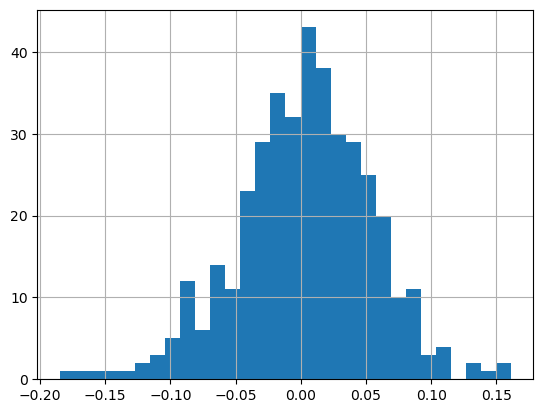

In [40]:
pdf['diff'] = pdf['made_home'] / pdf['attempts_home'] - pdf['made_away'] / pdf['attempts_away']
pdf['diff'].hist(bins=30)

In [41]:
# The histogram is centered near 0.
# It means most players have similar home and away performance.